# Solve surface volatiles according to outgassing+chemistry

In [1]:
import sys
sys.path.append("..")
from calliope.solve import *
from calliope.structure import calculate_mantle_mass
from calliope.constants import R_earth, const_G, M_earth

from copy import deepcopy
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from cmcrameri import cm
%matplotlib inline

### Set up initial options dict

In [2]:
OPTIONS = {}

OPTIONS['Phi_global'] = 0.01
OPTIONS['T_magma'] = 1600.0

OPTIONS['radius'] = R_earth * 1.5
OPTIONS['mass']   = M_earth * 2.31
OPTIONS['gravity'] = const_G * OPTIONS['mass'] / (OPTIONS['radius']**2)
OPTIONS['hydrogen_earth_oceans'] = 10.0
OPTIONS['CH_ratio'] = 0.1
OPTIONS['fO2_shift_IW'] = -3.0
OPTIONS['nitrogen_ppmw'] = 4.0
OPTIONS['sulfur_ppmw'] = 3000.0
OPTIONS['planet_coresize'] = 0.55

solvevol_vols = ['H2O', 'CO2', 'N2', 'H2', 'CO', 'CH4', 'S2', 'SO2', 'H2S', 'NH3']
for v in solvevol_vols:
    OPTIONS[v+"_included"] = 0
    OPTIONS[v+"_initial_bar"] = 0.0

OPTIONS["H2O_included"] = 1
OPTIONS["CO2_included"] = 1
OPTIONS["N2_included"]  = 1
OPTIONS["S2_included"]  = 1

OPTIONS["H2_included"]  = 1
OPTIONS["CO_included"]  = 1
OPTIONS["CH4_included"] = 1
OPTIONS["SO2_included"] = 1
OPTIONS["H2S_included"] = 1
OPTIONS["NH3_included"] = 1

# OPTIONS["H2O_initial_bar"] = 1.0
# OPTIONS["CO2_initial_bar"] = 0.0
# OPTIONS["N2_initial_bar"]  = 0.0

print("Gravity = %.3f m.s-2" % OPTIONS["gravity"])



Gravity = 10.195 m.s-2


### Calculate total amount of each element in the system

In [3]:
OPTIONS["M_mantle"] = calculate_mantle_mass(OPTIONS["radius"], OPTIONS["mass"], OPTIONS["planet_coresize"])
BACKUP_options = deepcopy(OPTIONS)

In [4]:
solvevol_target = get_target_from_params(OPTIONS)
print(solvevol_target)

{'H': 1.5499999999999997e+21, 'C': 1.5499999999999997e+20, 'N': 2.897912999999999e+19, 'S': 2.1734347499999995e+22}


### Parameter sweep demo

In [5]:
plt.close("all")

# parameters
x_key = "fO2_shift_IW"
x_lbl = r"log($f$O$_2$) - IW"
x_arr = np.linspace(-5, 5, 22)

y_key = "sulfur_ppmw"
y_lbl = r"S$_\text{ppmw}$"
y_arr = np.linspace(300, 9000, len(x_arr))

# out keys
z_out = {}
for k in [v+"_vmr" for v in solvevol_vols]:
    z_out[k] = []
for k in [v+"_bar" for v in solvevol_vols]:
    z_out[k] = []
z_out["atm_kg_per_mol"] = []

# run model
x_plt = []
y_plt = []
for i in range(len(x_arr)):
    for j in range(len(y_arr)):

        x = x_arr[i]
        y = y_arr[j]

        OPTIONS = deepcopy(BACKUP_options)
        OPTIONS[x_key] = x
        OPTIONS[y_key] = y

        solvevol_target = get_target_from_params(OPTIONS)
        p_d = equilibrium_atmosphere(solvevol_target, OPTIONS)
        for k in z_out.keys():
            z_out[k].append(p_d[k])

        x_plt.append(x)
        y_plt.append(y)

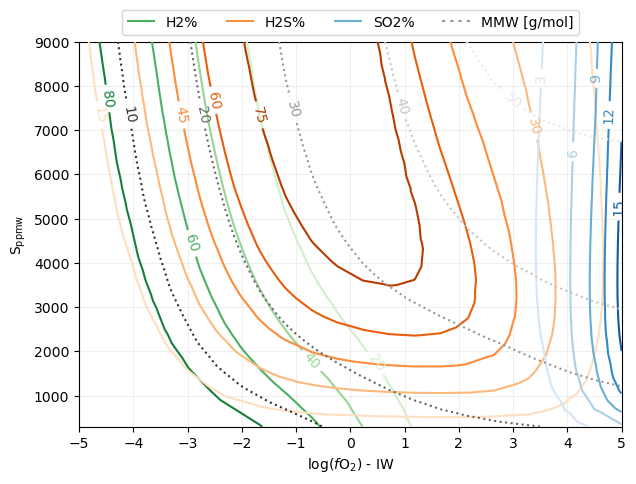

In [16]:
# plot data
fig,ax = plt.subplots(1,1, figsize=(7,5))

norm = 'linear'
vmin = 0.0
vmax = None
levs = 5
lw = 1.5

pairs = [
    ("H2_vmr","Greens",'solid'),
    # ("CO_vmr","Purples",'dashed'),
    ("H2S_vmr","Oranges",'solid'),
    ("SO2_vmr","Blues",'solid'),
    ("atm_kg_per_mol", "Greys_r",'dotted')]
artists, labels = [], []
for p in pairs:

    scale = 1.0
    if "vmr" in p[0]:
        scale = 1e2
        label = p[0].split("_")[0] + "%"
    elif "kg_per_mol" in p[0]:
        scale = 1e3
        label = "MMW [g/mol]"

    z_plt = np.array(z_out[p[0]]) * scale
    z_plt[z_plt<vmin] = 0

    cmap = deepcopy(plt.get_cmap(p[1]))

    cs = ax.tricontour(x_plt, y_plt, z_plt, norm=norm, vmin=vmin, vmax=vmax, cmap=cmap, levels=levs, linestyles=p[2], linewidths=lw, zorder=4)
    ax.clabel(cs,cs.levels, fmt="%.0f", fontsize=10)

    a, _ = cs.legend_elements()
    artists.append(a[3])
    labels.append(label)


ax.grid(zorder=-2,alpha=0.2)
ax.xaxis.set_major_locator(MultipleLocator(1))
ax.set(xlabel=x_lbl, ylabel=y_lbl)
ax.legend(artists, labels, loc='lower center', bbox_to_anchor=(0.5,1), ncols=5)
plt.show()
fig.savefig("nogit_contour.png",dpi=450)